In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import re
pd.set_option('display.max_columns',None)

In [71]:
eda_multi = pd.read_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\fe\featured_properties.csv")
eda_multi

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,balcony,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,NaN,1800.0,4,4,2,4.0,0,0,0,0,1,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.105538
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,NaN,2700.0,3,3,2,1.0,0,0,0,0,0,not available,Unfurnished,New Property,NaN,0.000000
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,NaN,4000.0,4,4,2,4.0,1,1,0,1,1,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.359981
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,NaN,NaN,4,5,3+,2.0,0,1,0,0,0,west,Unfurnished,Relatively New,"['Maintenance Staff', 'Swimming Pool', 'No ope...",0.204557
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,2002.0,NaN,3,3,3,3.0,0,1,0,0,0,east,Unfurnished,New Property,"['Power Back-up', 'Intercom Facility', 'Lift(s...",0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,NaN,NaN,8,8,2,4.0,0,0,0,1,0,north-east,Unfurnished,New Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.742970
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,NaN,NaN,3,2,2,2.0,0,0,0,0,0,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1.146893
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,NaN,NaN,2,2,3,3.0,0,0,0,0,0,north-east,Unfurnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",1.326750
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,NaN,NaN,4,4,2,4.0,0,1,0,1,0,east,Semi-Furnished,New Property,"['Centrally Air Conditioned', 'Security / Fire...",1.235554


### 1. Sector vs Area 

In [69]:
eda_multi.groupby("bedrooms")["price_per_sqft"].median()

bedrooms
1      15555.5
2      13740.0
3      14581.5
4      15740.0
5      33121.0
6      37037.0
7      35948.0
8      37600.0
9      36492.0
10     36127.0
11     50299.5
12     44444.0
13     60655.5
14     42299.0
15     41339.5
16     53094.0
17     21244.0
18     41152.0
19     55555.0
20     60386.0
21    135000.0
22     60076.5
23     48733.0
24     54629.5
28     42135.0
32     55334.0
35     31723.5
36     53333.0
48     35651.0
Name: price_per_sqft, dtype: float64

### 1. Property Type VS Price Per SQFT

In [3]:
eda_multi[['property_type','price_per_sqft']]

,property_type,price_per_sqft
0,Independent House,15333.0
1,Independent Builder Floor,15741.0
2,Independent Builder Floor,13125.0
3,Independent House,20000.0
4,Flat,15534.0
...,...,...
5975,Independent House,58333.0
5976,Independent Builder Floor,13000.0
5977,Independent Builder Floor,9277.0
5978,Independent Builder Floor,13207.0


In [6]:
median_price_per_sqft = eda_multi.groupby('property_type', as_index= False)['price_per_sqft'].median()
median_price_per_sqft

,property_type,price_per_sqft
0,Flat,14489.0
1,Independent Builder Floor,13731.5
2,Independent House,32300.0


In [7]:
fig = px.bar(data_frame= median_price_per_sqft
             , x ='property_type'
             , y = 'price_per_sqft'
             , text= 'price_per_sqft'
             ,title= "Median Price Per Sqft VS Property Type"
             ,labels= {"price_per_sqft":"Median Price Per Sqft","property_type":"Property Type"})
fig 

In [8]:
fig = px.box(data_frame= eda_multi, x = 'property_type', y = 'price_per_sqft')
fig

In [9]:
# check outliers
eda_multi[eda_multi['price_per_sqft'] > 100000][['property_type','society','sector','price_in_cr','price_per_sqft', 'super_built_up_area', 'built_up_area', 'carpet_area']]

,property_type,society,sector,price_in_cr,price_per_sqft,super_built_up_area,built_up_area,carpet_area
9,Independent House,Emaar MGF The Vilas,sector 24,21.00,583333.0,NaN,NaN,6800.0
164,Independent House,Home Heaven Associates,sector 105,0.98,139985.0,NaN,1450.0,NaN
186,Independent House,"Ardee City, Gurgaon",sector 52,6.55,272916.0,NaN,4500.0,NaN
193,Independent House,Urban Estate Residents Welfare Association,sector 4,4.00,256250.0,NaN,NaN,NaN
367,Independent House,"Gwal Pahari, Gurgaon",gwal pahari,3.90,112391.0,NaN,5000.0,4200.0
...,...,...,...,...,...,...,...,...
5454,Independent House,"Sector 46, Gurgaon",sector 46,5.25,312500.0,NaN,NaN,168.0
5457,Independent House,DLF City Plots Phase 3,sector 24,2.50,416666.0,NaN,NaN,1500.0
5530,Independent Builder Floor,Oriental Homes,sector 57,3.95,131666.0,300.0,NaN,NaN
5826,Independent House,"Sector 46, Gurgaon",sector 46,5.60,414814.0,NaN,3300.0,3000.0


### 2. Property Type VS built_up_area

In [12]:
eda_multi[['property_type','built_up_area']]

,property_type,built_up_area
0,Independent House,NaN
1,Independent Builder Floor,NaN
2,Independent Builder Floor,NaN
3,Independent House,NaN
4,Flat,2002.0
...,...,...
5975,Independent House,NaN
5976,Independent Builder Floor,NaN
5977,Independent Builder Floor,NaN
5978,Independent Builder Floor,NaN


In [13]:
median_builtup_area = eda_multi.groupby('property_type',as_index=False)['built_up_area'].median()
median_builtup_area

,property_type,built_up_area
0,Flat,1754.0
1,Independent Builder Floor,2430.0
2,Independent House,2515.0


In [14]:
fig = px.bar(data_frame= median_builtup_area,
              x = 'property_type'
             , y ='built_up_area'
             , title= 'Median Builup Area vs Property Type'
             , labels= {"built_up_area":"Median BuiltUp Area","property_type":"Property Type"}
             , text= 'built_up_area'
             )
fig

In [15]:
fig = px.box(data_frame= eda_multi, x='property_type', y='built_up_area')
fig

In [17]:
eda_multi[eda_multi['built_up_area'] >=10000 ]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,balcony,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
2476,Y83934748,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Adani Samsara Avasa,sector 63,4.3,2172.0,2700 sqft (250.84 sqm) Plot Area | 22500 sqft ...,2700.0,NaN,22500.0,19800.0,4,5,3+,3.0,0,1,0,1,1,east,Furnished,Undefined,0.008978
5008,T84187970,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Tata Primanti,sector 72,16.0,2091.0,3240 sqft (301.01 sqm) Plot Area | 76500 sqft ...,3240.0,NaN,76500.0,61200.0,4,4,3+,4.0,1,1,1,1,0,north-east,Semi-Furnished,Moderately Old,0.009861
5010,B63658124,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Anant Raj Manor Villas,sector 63,10.5,37037.0,2700 sqft (250.84 sqm) Plot Area | 46800 sqft ...,2700.0,NaN,46800.0,NaN,5,6,3+,3.0,0,1,0,0,0,north-west,Unfurnished,Relatively New,0.008387


### 4. Property Type VS super_built_up_area

In [19]:
eda_multi[['property_type','super_built_up_area']]

,property_type,super_built_up_area
0,Independent House,NaN
1,Independent Builder Floor,NaN
2,Independent Builder Floor,NaN
3,Independent House,NaN
4,Flat,NaN
...,...,...
5975,Independent House,NaN
5976,Independent Builder Floor,1656.0
5977,Independent Builder Floor,1024.0
5978,Independent Builder Floor,2650.0


In [20]:
median_super_builtup_area = eda_multi.groupby('property_type',as_index=False)['super_built_up_area'].median()
median_super_builtup_area

,property_type,super_built_up_area
0,Flat,1945.0
1,Independent Builder Floor,2430.0
2,Independent House,NaN


### 5. property_type vs FloorNum

In [23]:
eda_multi[['property_type','floornum']]

,property_type,floornum
0,Independent House,4.0
1,Independent Builder Floor,1.0
2,Independent Builder Floor,4.0
3,Independent House,2.0
4,Flat,3.0
...,...,...
5975,Independent House,4.0
5976,Independent Builder Floor,2.0
5977,Independent Builder Floor,3.0
5978,Independent Builder Floor,4.0


In [27]:
avg_floornum  = eda_multi.groupby('property_type', as_index= False)['floornum'].median()
avg_floornum

,property_type,floornum
0,Flat,9.0
1,Independent Builder Floor,2.0
2,Independent House,3.0


In [29]:
fig = px.bar(data_frame= avg_floornum
             , x ='property_type'
             , y = 'floornum'
             , title= "Property type vs Floor Num "
             , text= 'floornum'
             , color= 'property_type')
fig

c:\ProgramData\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [30]:
fig = px.box(data_frame= eda_multi, x = 'property_type', y = 'floornum')
fig

In [31]:
# checking for outliers
eda_multi[(eda_multi['property_type'] == 'Independent House') & (eda_multi['floornum'] > 10)]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,balcony,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
158,J83212258,Independent House,https://www.99acres.com/1-bhk-bedroom-independ...,"Sector 1A IMT Manesar, Gurgaon",sector 1,0.19,2897.0,654 sqft (60.76 sqm) Plot Area,654.0,NaN,NaN,NaN,1,1,2,14.0,0,0,0,1,0,north-east,Unfurnished,Relatively New,0.002109
241,Y83318754,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,Paras Dews,sector 106,1.95,11079.0,1760 sqft (163.51 sqm) Plot Area | 1700 sqft (...,1760.0,NaN,1700.0,1200.0,3,3,3,23.0,0,1,0,0,0,east,Unfurnished,Relatively New,0.008244
376,O83546312,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Experion Windchants,sector 112,8.50,13438.0,6325 sqft (587.61 sqm) Built-up Area,NaN,NaN,6325.0,NaN,5,5,3+,28.0,1,1,0,1,0,north,Unfurnished,Relatively New,0.006738
452,A84079734,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Eros Rosewood City,sector 49,8.50,18889.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,NaN,NaN,5,6,3+,13.0,1,1,0,1,1,north-east,Furnished,Old Property,0.001453
918,P82891986,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,"Medicity, Gurgaon",sector 38,9.00,61350.0,1467 sqft (136.29 sqm) Plot Area,1467.0,NaN,NaN,NaN,4,4,3+,13.0,0,0,0,0,1,north-east,Unfurnished,Relatively New,0.000227
933,R84238386,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,ROF Aalayas,sector 102,0.84,13007.0,645 sqft (59.92 sqm) Plot Area,645.0,NaN,NaN,NaN,3,2,3,14.0,0,0,0,0,0,east,Unfurnished,New Property,0.000719
1214,E83083944,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,Krisumi Waterfall Residences,sector 36,3.80,20000.0,1900 sqft (176.52 sqm) Plot Area,1900.0,NaN,NaN,NaN,2,3,2,35.0,0,1,0,1,0,north-east,Unfurnished,Relatively New,0.008574
1357,K82012048,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Sector 104, Gurgaon",sector 104,4.68,16519.0,2833 sqft (263.19 sqm) Plot Area,2833.0,NaN,NaN,NaN,3,4,3+,43.0,0,0,0,0,0,east,Unfurnished,Undefined,0.002109
3265,A82086164,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Experion Windchants,sector 112,8.25,13043.0,6325 sqft (587.61 sqm) Built-up Area,NaN,NaN,6325.0,NaN,5,6,3+,28.0,1,1,0,1,0,west,Unfurnished,Relatively New,0.007335
3795,R82898648,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,MRG The Meridian,sector 89,0.75,11986.0,626 sqft (58.13 sqm) Plot Area,626.0,NaN,NaN,NaN,2,2,3,24.0,0,0,0,0,0,not available,Unfurnished,Undefined,0.000850


- Conclusion houses(villa) but in appartments

In [32]:
property_age_cate = pd.crosstab(eda_multi['property_type'],eda_multi['age_possession_category'])
property_age_cate

age_possession_category,Moderately Old,New Property,Old Property,Relatively New,Undefined,Under Construction
property_type,,,,,,
Flat,486,512,131,1327,4,0
Independent Builder Floor,29,825,9,388,1,0
Independent House,682,248,544,679,105,10


In [33]:
pt = pd.pivot_table(eda_multi, index='property_type',columns='age_possession_category',values='price_in_cr',aggfunc='mean').reset_index()
pt

age_possession_category,property_type,Moderately Old,New Property,Old Property,Relatively New,Undefined,Under Construction
0,Flat,3.452490,2.992285,4.909008,3.339668,2.995000,NaN
1,Independent Builder Floor,2.440690,3.836461,2.745556,3.405052,3.950000,NaN
2,Independent House,8.989809,7.597317,7.330239,9.616514,4.642286,1.579


<Axes: xlabel='age_possession_category', ylabel='property_type'>

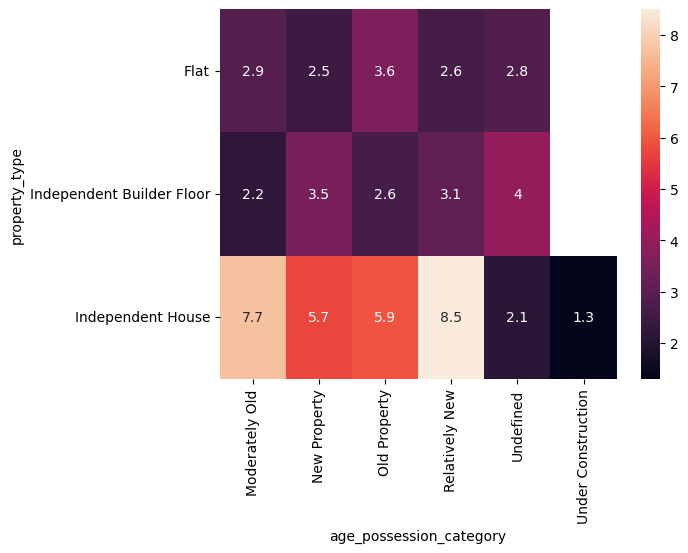

In [34]:
sns.heatmap(pd.pivot_table(eda_multi, index='property_type',columns='age_possession_category',values='price_in_cr',aggfunc='median')
,annot= True)

In [35]:
eda_multi

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,balcony,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,NaN,1800.0,4,4,2,4.0,0,0,0,0,1,north-east,Unfurnished,New Property,0.005538
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,NaN,2700.0,3,3,2,1.0,0,0,0,0,0,not available,Unfurnished,New Property,0.000000
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,NaN,4000.0,4,4,2,4.0,1,1,0,1,1,east,Furnished,Relatively New,0.002501
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,NaN,NaN,4,5,3+,2.0,0,1,0,0,0,west,Unfurnished,Relatively New,0.003063
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,2002.0,NaN,3,3,3,3.0,0,1,0,0,0,east,Unfurnished,New Property,0.003411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,NaN,NaN,8,8,2,4.0,0,0,0,1,0,north-east,Unfurnished,New Property,0.002046
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,NaN,NaN,3,2,2,2.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.007125
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,NaN,NaN,2,2,3,3.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.010188
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,NaN,NaN,4,4,2,4.0,0,1,0,1,0,east,Semi-Furnished,New Property,0.009143


### 6. property_type vs bedRoom

<Axes: xlabel='bedrooms', ylabel='property_type'>

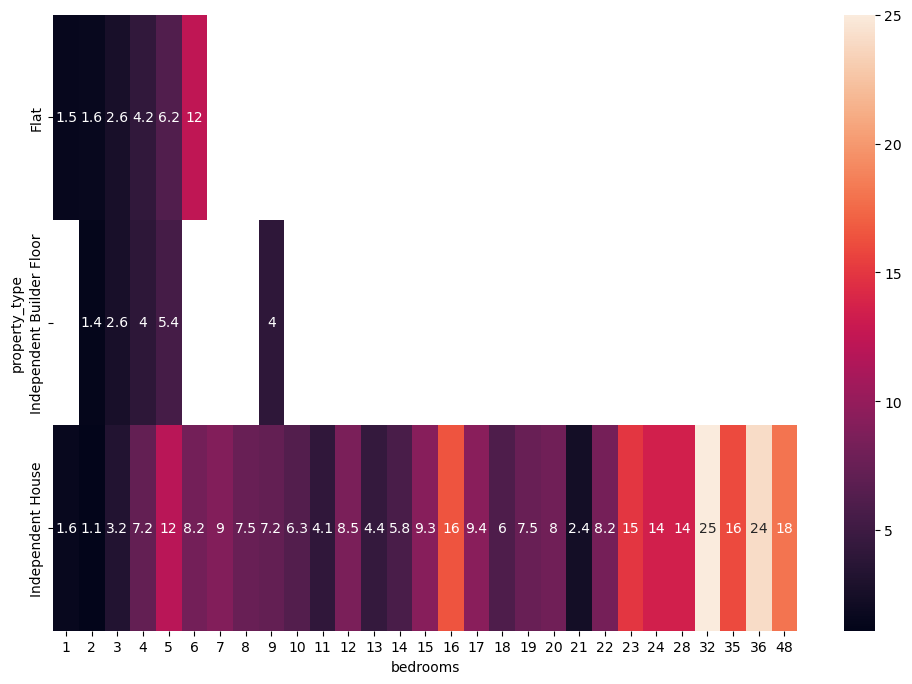

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(pd.pivot_table(eda_multi, index='property_type',columns='bedrooms',values='price_in_cr',aggfunc='median')
,annot= True)

### 7. property_type vs furnishing_type

<Axes: xlabel='furnishing_type', ylabel='property_type'>

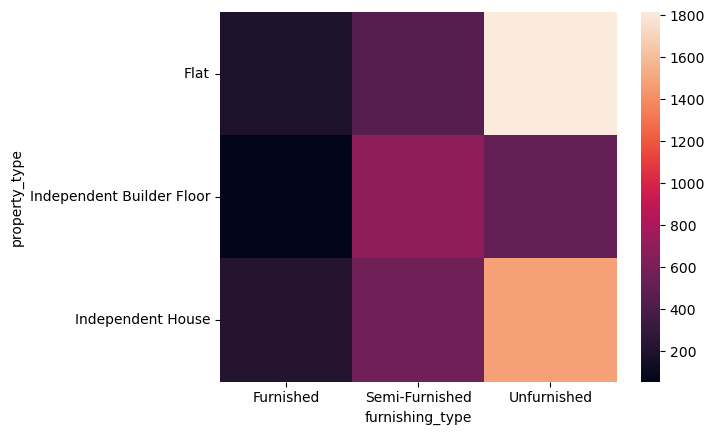

In [39]:
sns.heatmap(pd.crosstab(eda_multi['property_type'],eda_multi['furnishing_type']))

<Axes: xlabel='furnishing_type', ylabel='property_type'>

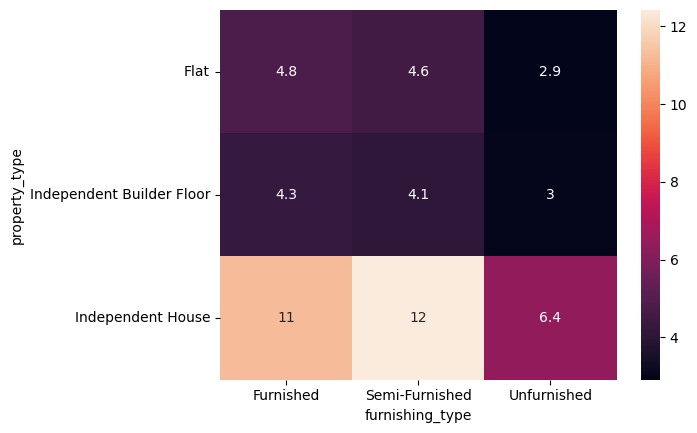

In [40]:
sns.heatmap(pd.pivot_table(eda_multi,index='property_type',columns='furnishing_type',values='price_in_cr',aggfunc='mean'),annot=True)

### 8. property_type vs luxuary Score

In [41]:
avg_luxury_score = eda_multi.groupby('property_type',as_index= False)['luxury_score'].mean()

px.bar(data_frame= avg_luxury_score,x='property_type',y='luxury_score', text= 'luxury_score')

In [42]:
px.box(data_frame= eda_multi,x='property_type',y='luxury_score')

#### 9. Property Type VS Sector

<Axes: xlabel='sector', ylabel='property_type'>

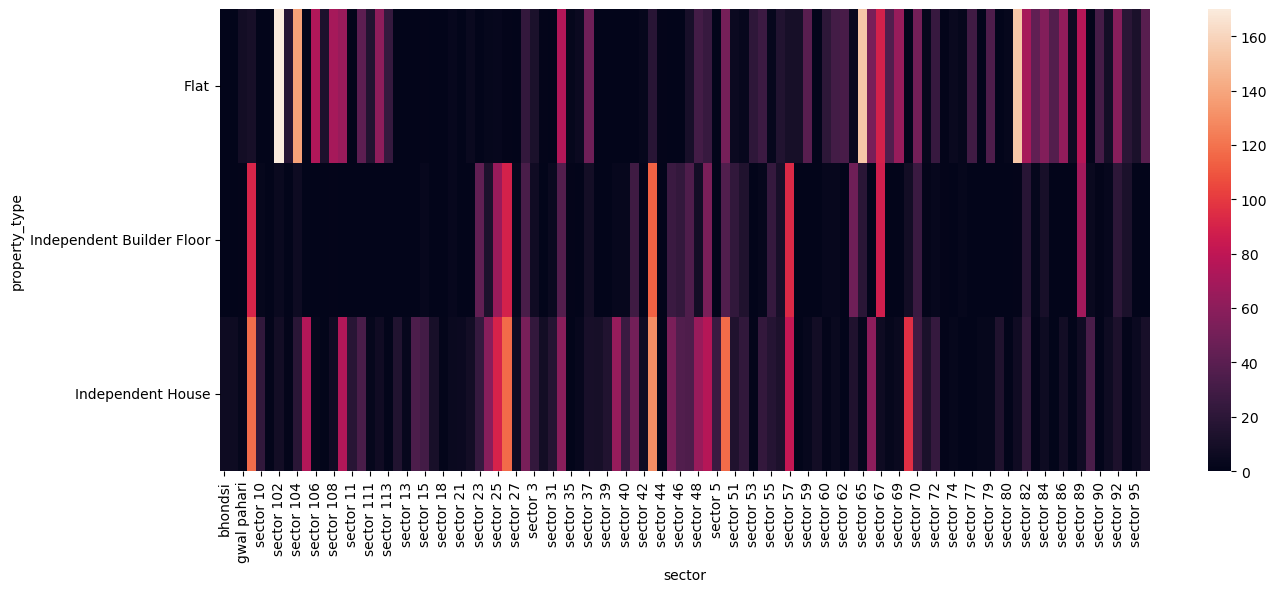

In [43]:
# sector analysis
plt.figure(figsize=(15,6))
sns.heatmap(pd.crosstab(eda_multi['property_type'],eda_multi['sector'].sort_index()))

Sector that are above 70 are new in gurgaon and we can see relatively more properties are there compared to old sector.

#### 10. Sector vs Price_in_cr

In [44]:
median_sector_price = eda_multi.groupby('sector')['price_in_cr'].median().round(2).to_frame().reset_index()
median_sector_price

,sector,price_in_cr
0,bhondsi,0.78
1,farukhnagar,0.88
2,gwal pahari,2.03
3,sector 1,3.50
4,sector 10,2.50
...,...,...
97,sector 91,2.88
98,sector 92,2.25
99,sector 93,1.90
100,sector 95,0.64


In [45]:
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')

median_sector_price['sector_number'] = median_sector_price['sector'].apply(extract_sector_number).to_frame()
median_sector_price = median_sector_price.sort_values(by='sector_number').set_index('sector').drop(columns='sector_number')
median_sector_price

,price_in_cr
sector,
sector 1,3.50
sector 2,3.20
sector 3,1.20
sector 4,4.10
sector 5,2.98
...,...
sector 112,5.88
sector 113,3.20
gwal pahari,2.03


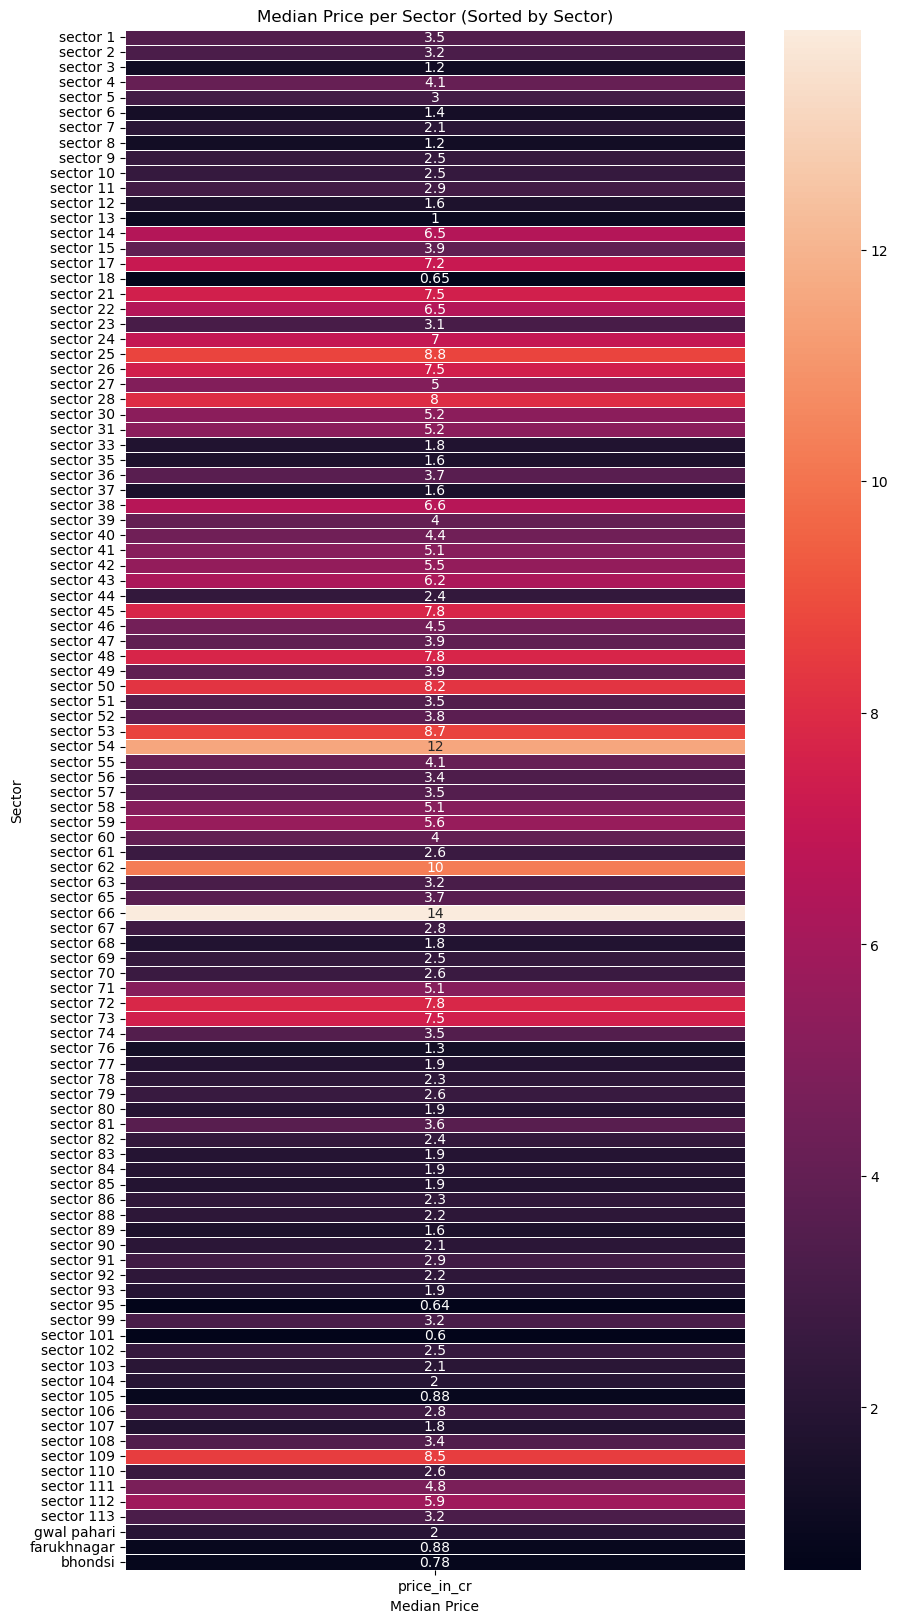

In [46]:
plt.figure(figsize=(10, 20))  
sns.heatmap(median_sector_price, annot=True,linewidths=.5)
plt.title('Median Price per Sector (Sorted by Sector)')
plt.xlabel('Median Price')
plt.ylabel('Sector')
plt.show()

- sector 1 to 10 are bit old sectors and due to that prices are low. 

### 11. Sector vs Price Per Sqft

In [47]:
median_sector_price_per_sqft = eda_multi.groupby('sector')['price_per_sqft'].median().round(2).to_frame().reset_index()
median_sector_price_per_sqft

,sector,price_per_sqft
0,bhondsi,6168.5
1,farukhnagar,8423.0
2,gwal pahari,13274.0
3,sector 1,16422.0
4,sector 10,24785.5
...,...,...
97,sector 91,13070.0
98,sector 92,10962.0
99,sector 93,11588.5
100,sector 95,9918.0


In [48]:
median_sector_price_per_sqft['sector_number'] = median_sector_price_per_sqft['sector'].apply(extract_sector_number).to_frame()
median_sector_price_per_sqft = median_sector_price_per_sqft.sort_values(by='sector_number').set_index('sector').drop(columns='sector_number')
median_sector_price_per_sqft

,price_per_sqft
sector,
sector 1,16422.0
sector 2,17816.5
sector 3,10105.0
sector 4,20068.0
sector 5,20668.5
...,...
sector 112,15822.0
sector 113,15238.0
gwal pahari,13274.0


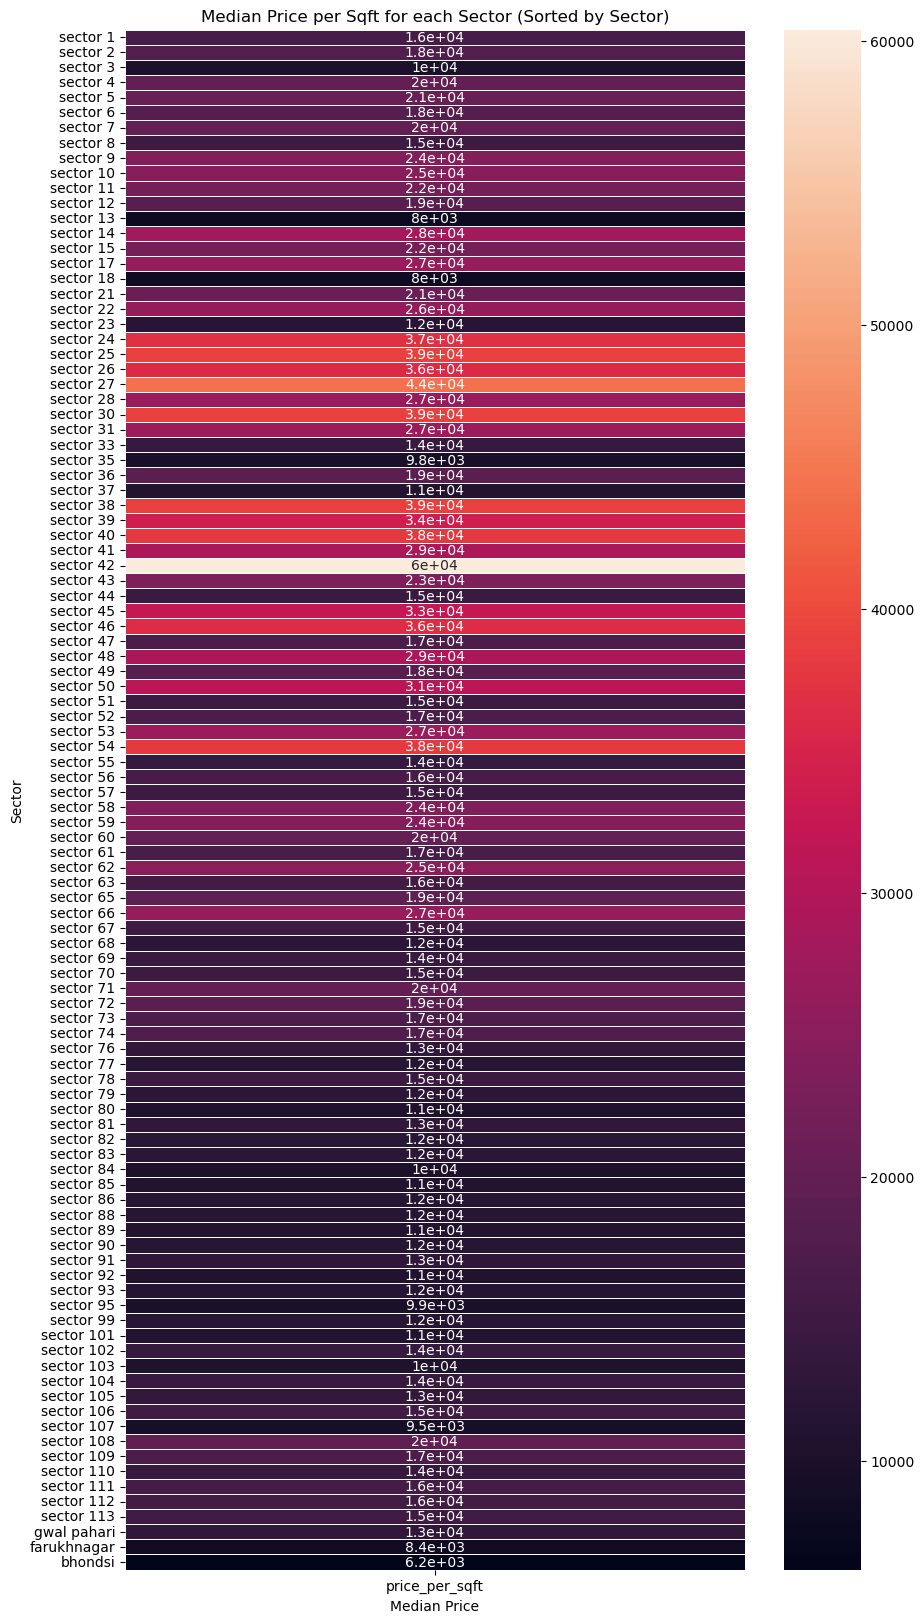

In [49]:
plt.figure(figsize=(10, 20))  
sns.heatmap(median_sector_price_per_sqft, annot=True,linewidths=.5)
plt.title('Median Price per Sqft for each Sector (Sorted by Sector)')
plt.xlabel('Median Price')
plt.ylabel('Sector')
plt.show()

In [50]:
avg_luxury_score_per_sector = eda_multi.groupby('sector')['luxury_score_norm'].mean().round(2).to_frame().reset_index()
avg_luxury_score_per_sector

KeyError: 'Column not found: luxury_score_norm'

In [ ]:
avg_luxury_score_per_sector['sector_number'] = avg_luxury_score_per_sector['sector'].apply(extract_sector_number).to_frame()
avg_luxury_score_per_sector = avg_luxury_score_per_sector.sort_values(by='sector_number').set_index('sector').drop(columns='sector_number')
avg_luxury_score_per_sector

,luxury_score_norm
sector,
sector 1,0.00
sector 2,0.00
sector 3,0.01
sector 4,0.00
sector 5,0.00
...,...
sector 113,0.01
Greater Gurugram,0.01
dwarka expressway,0.00


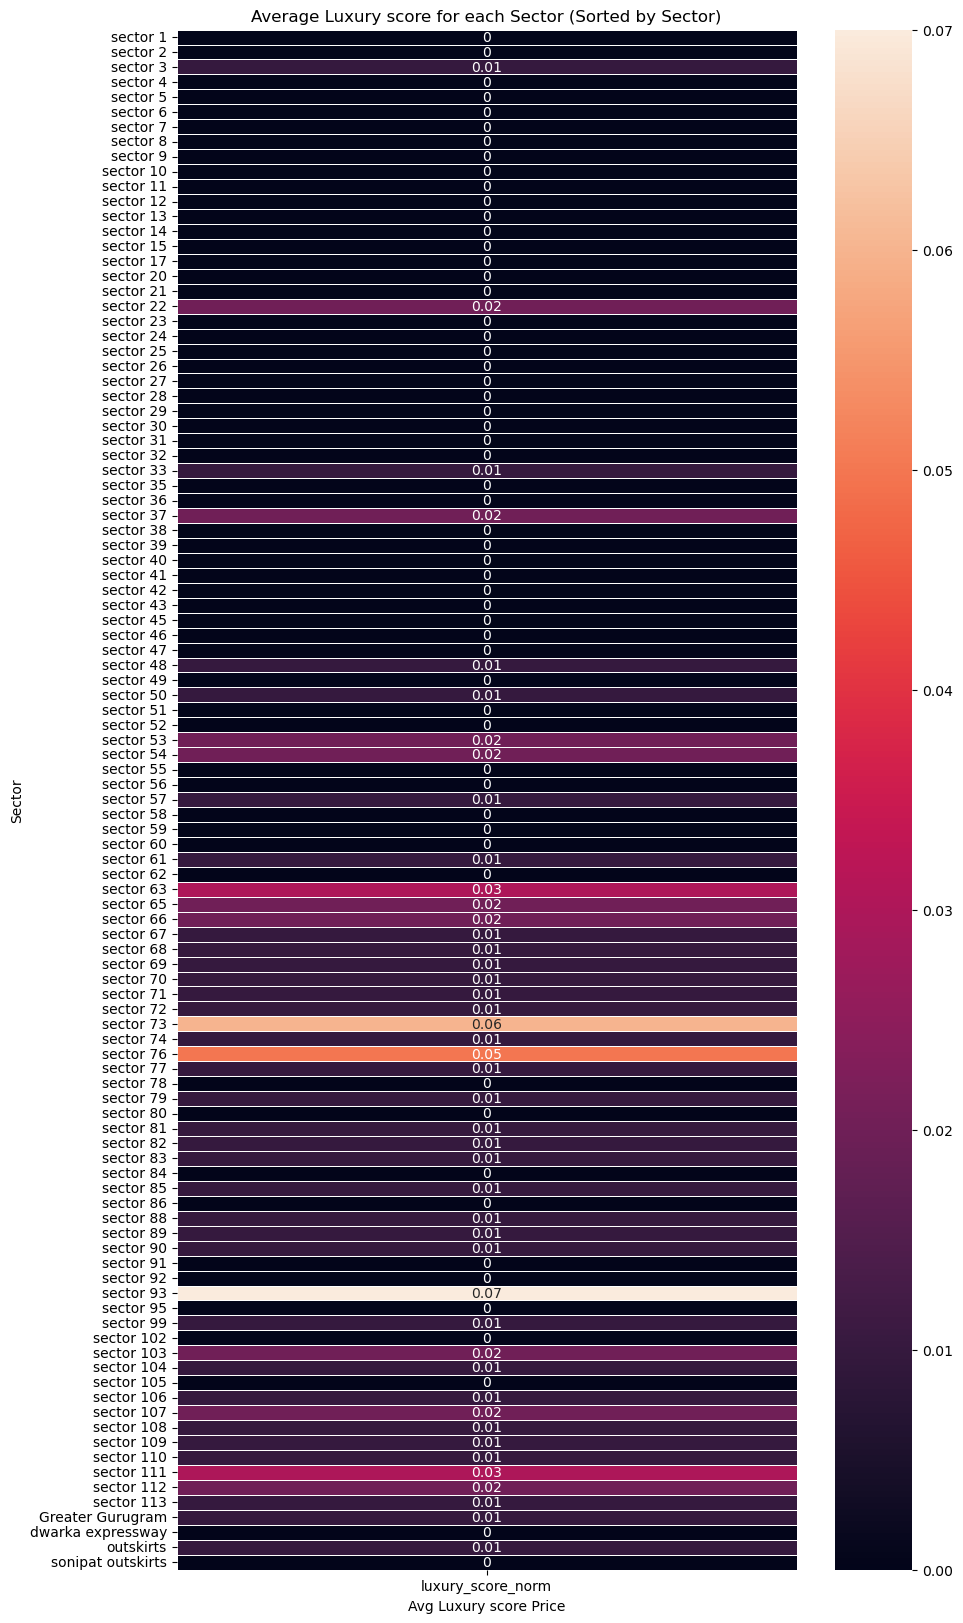

In [ ]:
plt.figure(figsize=(10, 20))  
sns.heatmap(avg_luxury_score_per_sector, annot=True,linewidths=.5)
plt.title('Average Luxury score for each Sector (Sorted by Sector)')
plt.xlabel('Avg Luxury score Price')
plt.ylabel('Sector')
plt.show()

#### 12. Price_in_cr VS Bedroom

In [51]:
price_vs_bedroom = pd.pivot_table(data= eda_multi, index= 'bedrooms', values= 'price_in_cr', aggfunc= 'median').round(2).reset_index()
price_vs_bedroom

,bedrooms,price_in_cr
0,1,1.50
1,2,1.55
2,3,2.65
3,4,4.30
4,5,11.50
5,6,8.15
6,7,9.00
7,8,7.50
8,9,7.25
9,10,6.30


In [52]:
price_vs_bedroom["bedrooms"] = price_vs_bedroom["bedrooms"].astype(str)

fig = px.bar(
    data_frame=price_vs_bedroom,
    x='bedrooms',
    y='price_in_cr',
    text='price_in_cr',
    labels={"price_in_cr": "Price (Cr)", "bedrooms": "Bedrooms"}
)

fig.show()


#### 13. Price_in_cr vs Age Possession

In [53]:
eda_multi.columns

Index(['property_id', 'property_type', 'link', 'society', 'sector',
       'price_in_cr', 'price_per_sqft', 'areawithtype', 'plot_area',
       'super_built_up_area', 'built_up_area', 'carpet_area', 'bedrooms',
       'bathrooms', 'balcony', 'floornum', 'study_room', 'servant_room',
       'store_room', 'pooja_room', 'others', 'facing', 'furnishing_type',
       'age_possession_category', 'luxury_score'],
      dtype='object')

In [54]:
eda_multi[['price_in_cr','age_possession_category']]

,price_in_cr,age_possession_category
0,2.76,New Property
1,4.25,New Property
2,5.25,Relatively New
3,9.00,Relatively New
4,3.11,New Property
...,...,...
5975,5.25,New Property
5976,2.15,New Property
5977,0.95,New Property
5978,3.50,New Property


In [55]:
price_vs_age = pd.pivot_table(data= eda_multi, index= 'age_possession_category', values= 'price_in_cr', aggfunc= 'median').round(2).reset_index()
price_vs_age

,age_possession_category,price_in_cr
0,Moderately Old,4.20
1,New Property,3.15
2,Old Property,5.25
3,Relatively New,3.20
4,Undefined,2.17
5,Under Construction,1.31


In [56]:
fig = px.bar(
    data_frame=price_vs_age,
    x='age_possession_category',
    y='price_in_cr',
    text='price_in_cr',
    labels={"price_in_cr": "Price (Cr)", "age_possession_category": "Properties Age"}
)

fig.show()

Possible Reasons Why Old Properties Are More Expensive:
1. Location Advantage
Older properties are often located in prime, fully developed localities (e.g., central Gurgaon, Golf Course Road).

Newer properties may be in emerging or peripheral sectors, where prices are lower.

2. Bigger Plot Sizes
Older constructions may be on larger plots or have more built-up area, which significantly drives up the price.

Newer units are often more compact due to modern architecture norms and land constraints.

3. Independent vs Builder Floors or Flats
Many old listings could be independent houses, which are priced higher due to land ownership.

Newer listings might be builder floors or high-rise apartments, which are cheaper per unit.

4. Prestigious Societies or Historic Value
Some old properties may be in prestigious or legacy societies (e.g., DLF Phase 1, South City).

Even if the building is old, the brand value of the area increases demand and pricing.

5. Renovated High-End Homes
"Old Property" doesn’t mean “run-down.” Many old houses are renovated or rebuilt luxury homes, especially in high-demand areas.

In [57]:
eda_multi['age_possession_category'].value_counts()

age_possession_category
Relatively New        2394
New Property          1585
Moderately Old        1197
Old Property           684
Undefined              110
Under Construction      10
Name: count, dtype: int64

In [58]:
eda_multi.groupby('age_possession_category')['price_in_cr'].describe()

,count,mean,std,min,25%,50%,75%,max
age_possession_category,,,,,,,,
Moderately Old,1195.0,6.578879,6.283410,0.17,2.3000,4.200,9.25,57.0
New Property,1583.0,4.147865,3.761419,0.30,2.3000,3.150,4.50,40.0
Old Property,684.0,6.806199,5.774158,0.20,3.0000,5.250,8.75,48.0
Relatively New,2392.0,5.126789,5.177801,0.19,2.2475,3.200,5.90,80.0
Undefined,110.0,4.576091,6.388421,0.26,1.1600,2.175,6.00,37.0
Under Construction,10.0,1.579000,1.080437,0.80,1.1250,1.305,1.35,4.5


In [59]:
eda_multi.groupby('age_possession_category')['price_in_cr'].median()


age_possession_category
Moderately Old        4.200
New Property          3.150
Old Property          5.250
Relatively New        3.200
Undefined             2.175
Under Construction    1.305
Name: price_in_cr, dtype: float64

#### Price_in_cr vs furnishing_type

In [60]:
price_vs_fur_type = pd.pivot_table(data= eda_multi, index= 'furnishing_type', values= 'price_in_cr', aggfunc= 'median').round(2).reset_index()
price_vs_fur_type

,furnishing_type,price_in_cr
0,Furnished,4.90
1,Semi-Furnished,4.60
2,Unfurnished,2.75


#### Correlations

In [61]:
numeric_df = eda_multi.select_dtypes(include=['number'])

corre_matrix = numeric_df.corr()

corre_matrix

,price_in_cr,price_per_sqft,plot_area,super_built_up_area,built_up_area,carpet_area,bedrooms,bathrooms,floornum,study_room,servant_room,store_room,pooja_room,others,luxury_score
price_in_cr,1.000000,0.310500,0.733475,0.760402,0.431892,0.404532,0.396092,0.474635,-0.110853,0.299784,0.362735,0.315438,0.317612,0.025511,0.011075
price_per_sqft,0.310500,1.000000,-0.154322,0.172839,0.027361,0.051383,0.244491,0.245411,-0.097179,0.081497,0.055399,0.108392,0.091076,-0.008151,-0.089078
plot_area,0.733475,-0.154322,1.000000,NaN,0.296185,0.227627,0.121207,0.211610,-0.010163,0.322131,0.446565,0.238036,0.286208,0.030250,0.353074
super_built_up_area,0.760402,0.172839,NaN,1.000000,NaN,NaN,0.724854,0.726140,0.091015,0.065666,0.497147,0.080219,0.218455,-0.063463,0.010147
built_up_area,0.431892,0.027361,0.296185,NaN,1.000000,0.996130,0.159102,0.225395,-0.013200,0.176424,0.289468,0.180290,0.189253,-0.029059,0.213165
carpet_area,0.404532,0.051383,0.227627,NaN,0.996130,1.000000,0.142642,0.184199,-0.044163,0.132077,0.227720,0.173147,0.207032,-0.018625,0.146103
bedrooms,0.396092,0.244491,0.121207,0.724854,0.159102,0.142642,1.000000,0.932798,-0.170022,0.068092,0.091902,0.136471,0.159689,0.020672,-0.200238
bathrooms,0.474635,0.245411,0.211610,0.726140,0.225395,0.184199,0.932798,1.000000,-0.116353,0.108811,0.207773,0.166509,0.193507,0.015547,-0.115011
floornum,-0.110853,-0.097179,-0.010163,0.091015,-0.013200,-0.044163,-0.170022,-0.116353,1.000000,-0.122444,0.045421,-0.114043,-0.188281,-0.077438,0.324657
study_room,0.299784,0.081497,0.322131,0.065666,0.176424,0.132077,0.068092,0.108811,-0.122444,1.000000,0.237637,0.314819,0.390218,0.126040,0.094099


<Axes: >

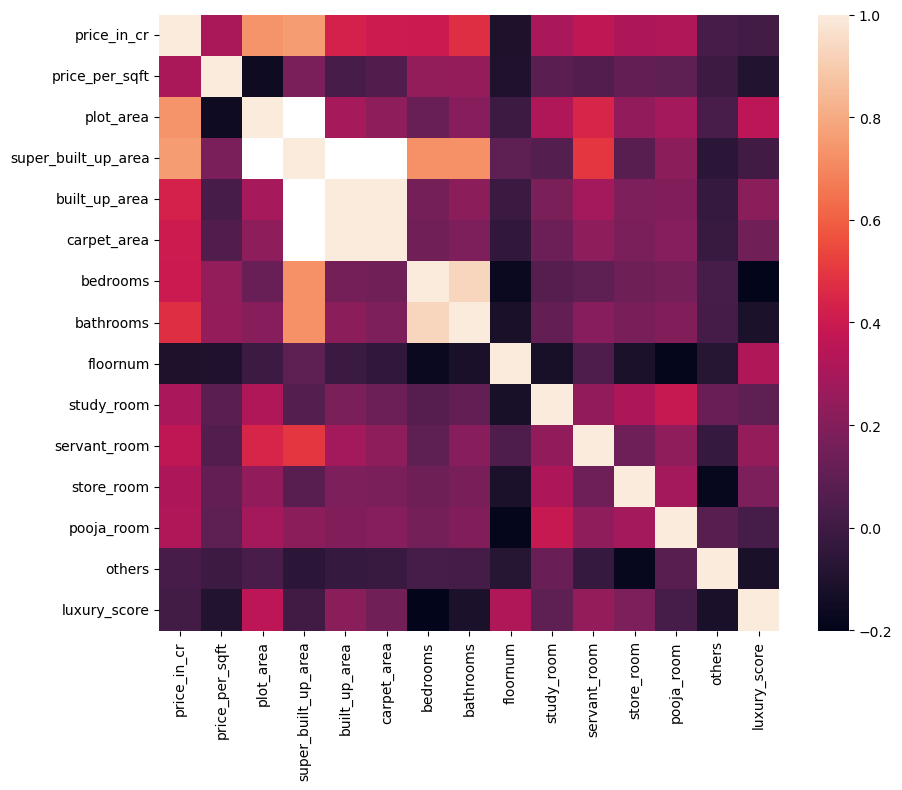

In [62]:
plt.figure(figsize=(10,8))
sns.heatmap(corre_matrix)

In [63]:
corre_matrix['price_in_cr']

price_in_cr            1.000000
price_per_sqft         0.310500
plot_area              0.733475
super_built_up_area    0.760402
built_up_area          0.431892
carpet_area            0.404532
bedrooms               0.396092
bathrooms              0.474635
floornum              -0.110853
study_room             0.299784
servant_room           0.362735
store_room             0.315438
pooja_room             0.317612
others                 0.025511
luxury_score           0.011075
Name: price_in_cr, dtype: float64

In [64]:
eda_multi['carpet_area'].describe()

count     1027.000000
mean      2700.707887
std       3156.133660
min        120.000000
25%       1600.000000
50%       2286.000000
75%       3079.000000
max      61200.000000
Name: carpet_area, dtype: float64

In [65]:
eda_multi['carpet_area'].value_counts().head(10)

carpet_area
2700.0    67
3240.0    26
4500.0    25
2430.0    21
2160.0    20
2250.0    19
2000.0    19
1800.0    19
3000.0    19
4000.0    19
Name: count, dtype: int64

Red Flag: Outlier in carpet_area
Max = 607,936, but:

75% of the data is below 1,790

Mean = 2,523, which is inflated by extreme values

Std dev = 22,745 → huge spread

✅ Interpretation:
This clearly shows severe outliers — likely a data entry issue (e.g., someone entered 607,936 instead of 1,790).

📉 Why This Affects Correlation
Pearson correlation is very sensitive to outliers.

Even 1–2 extremely large carpet_area values with relatively low price_in_cr will pull the correlation downward.

